In [1]:
from ultralytics import YOLO
# We will be using YOLO, for this object detection project.

import cv2
# cv2: refers to OpenCV: means we will be using OpenCV (Open Computer Vision Library)
# helps us for video processing 

import pandas as pd
#  Data analysis library

import time
# Will be using time as this project includes Real-Time Edge-Based Dtection Systems
# Real Time means speed matters, so used for speed measurements

import os

print("All imports successful")


All imports successful


In [2]:
model = YOLO("yolov8n.pt")
# "yolov8n.pt" => version of YOLO we are going to use, YOLO version 8 nano,
# PyTorch model file: .pt
print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
video_path = "data/phone_walk.mp4"
# for file location

cap = cv2.VideoCapture(video_path)
# Inside cv2 module-> there is a function called VideoCapture.
# (video_path): passing argument = input to the function, we are giving it the path to video
# OpenCV or cv2 Captures the video that i will be using for this project

if not cap.isOpened():
    print("Error opening video")
    #  if the video is not opened
else:
    print("Video opened succesfully")
    # if the video is opened.

Video opened succesfully


In [4]:
# 1. INITIALIZE COUNTERS

frame_count = 0
# Tracks how many frames processed, later we need:
# Average inference time, # Frame indexing

total_inference_time = 0
# We accumulate all inference times, later:
# Average = total_time/frame_count

results_list = []
# [] means empty list



# 2. START INFINITE LOOP
#  Using while for infinite loop, we will manually stop it when video ends.
while True: # always true

    # 3. READ FRAME
    ret, frame =cap.read()
    # ret = true/false (was frame read succesfully)
    # frame = actual image (array)
    # cap.read() = reads one frame from video

    # Two variables because function returns two outputs
    
    # 4. STOP WHEN VIDEO ENDS
    if not ret:
        break
        # if ret is false: Video ended, stops the loop


    # 5. MEASURE START TIME
    start_time = time.time()
    # Returns current time in seconds.


    # 6. RUN YOLO
    results = model(frame, imgsz = 640, conf=0.25)
    # This performs inference.

    # Input: Frame image.
    # Output: Detection results.

    # Defualt precision = FP32


    # 7. MEASURE END TIME
    end_time = time.time()
    # end_time: measures end time


    # 8. COMPUTE INFERENCE TIME
    inference_time = end_time - start_time
    # this gives time taken to process one image


    # 9. ACCUMULATE TOTAL TIME
    total_inference_time += inference_time
    # += means: add and store, equivalent to: 
    # total_inference_time = total_inference_time + inference_time

    
    # 10. EXTRACT DETECTION INFO

    # YOLO may return multiple result objects.
    for r in results:
        for box in r.boxes:
            # Each detection is a box, which contains: Confidence, class, coordinates


            # 11. EXTRACT CONFIDENCE 
            confidence =float(box.conf[0])
            # box.conf = confidence tensor
            # [0] = first value
            # float() = converts tensor to standard number

            # 12. EXTRACT CLASS ID
            class_id = int(box.cls[0])
            # corresponds to object category.

        #  13. STORE IN DICTIONARY
        results_list.append({
            "frame": frame_count,
            "class_id": class_id,
            "confidence": confidence,
            "inference_time": inference_time
        })

    # 14. INCREASE FRAME COUNTER
    frame_count += 1
    # moves to next frame index

# 15. RELEASE VIDEO
cap.release()
# closes video file properly, important to free space

print("Processing complete.")

        


0: 640x480 9 persons, 4 cars, 372.3ms
Speed: 102.8ms preprocess, 372.3ms inference, 31.1ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 9 persons, 3 cars, 187.8ms
Speed: 11.1ms preprocess, 187.8ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 7 persons, 3 cars, 163.2ms
Speed: 6.1ms preprocess, 163.2ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 5 persons, 3 cars, 137.7ms
Speed: 9.3ms preprocess, 137.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 7 persons, 3 cars, 150.2ms
Speed: 5.0ms preprocess, 150.2ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 8 persons, 3 cars, 155.3ms
Speed: 5.6ms preprocess, 155.3ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 9 persons, 3 cars, 162.4ms
Speed: 5.8ms preprocess, 162.4ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 9 persons, 3 cars, 142.1m

In [5]:
df = pd.DataFrame(results_list)
# DataFrame: create table structure
# results_list: our collected detection dictionaries

print("Total Frames:", frame_count)

print("Average Inference Time:", total_inference_time/frame_count)
# Mathematically: this gives Mean inference latency per frame, this is one of our baseline metrics

print("Total Detections:", len(df))
# len(df): means count how many rows exist

df.head()
# shows first 5 rows.

Total Frames: 367
Average Inference Time: 0.18093543481436997
Total Detections: 367


,frame,class_id,confidence,inference_time
0,0,2,0.262798,0.827788
1,1,0,0.320720,0.213982
2,2,0,0.250250,0.183771
3,3,0,0.294566,0.158231
4,4,0,0.262413,0.169480


In [6]:
df.to_csv("outputs/day03_fp32_results.csv", index=False)
# Saves Results to CSV

print("Results saved successfully.")

Results saved successfully.


Mean Confidence: 0.31830115060065683
Confidence Standard Deviation: 0.08607033653634978


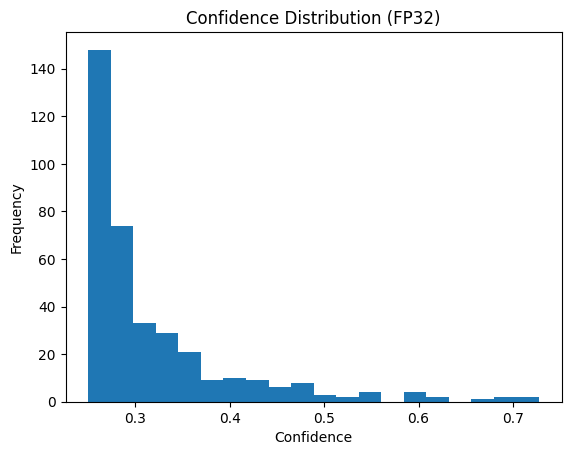

In [7]:
import matplotlib.pyplot as plt
#  A python Library for plotting Graphs
# .pyplot: sub-module of matplotlib used for drawing tools


mean_conf = df["confidence"].mean()
# df: dataframe: contains frame, class_id, confidence, inference time
# ["confidence"]: square brackets mean: access column named "confidence".
# so df["confidence"] means give me entire confidence column
# this is called a Series in pandas, 
# it is basically a list of numbers

# .mean(): gives mean of that column

std_conf = df["confidence"].std()
# gives standared deviation of that function

print("Mean Confidence:", mean_conf)
print("Confidence Standard Deviation:", std_conf)

plt.hist(df["confidence"], bins=20)
#  bins = 20, means divide confidence range into 20 intervals. 
# More bins = more detailed view
# fewer bins = smoother view.

# so this means plot how confidence values are distributed.

plt.title("Confidence Distribution (FP32)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

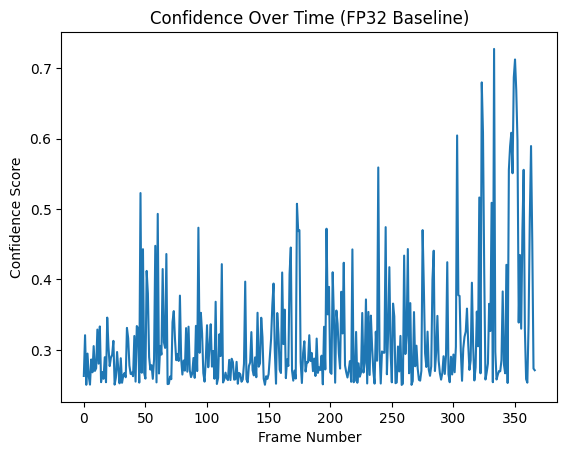

In [8]:
plt.figure()
# Creates a new blank plotting canvas, without this, plots can overlap.

plt.plot(df["frame"], df["confidence"])
# frame gets plotted against its confidence
#  produces a time-series graph

plt.xlabel("Frame Number")
# plots the X-axis label

plt.ylabel("Confidence Score")
# plots the Y-axis label

plt.title("Confidence Over Time (FP32 Baseline)")
# plots the Graph"s Name

plt.show()
# plots the graph needed.

##### Since we don't have a ground truth labels for our video, so for this we cannot compute accuracy.
##### but we can compute:
##### 1. Confidence distribution behaviour
##### 2. confidence stability
##### 3. Entropy
##### 4. Confidence spread per frame
##### 5. Detection consistency

Average detections per frame: 1.0
Max detections in a single frame: 1
Min detections in a single frame: 1


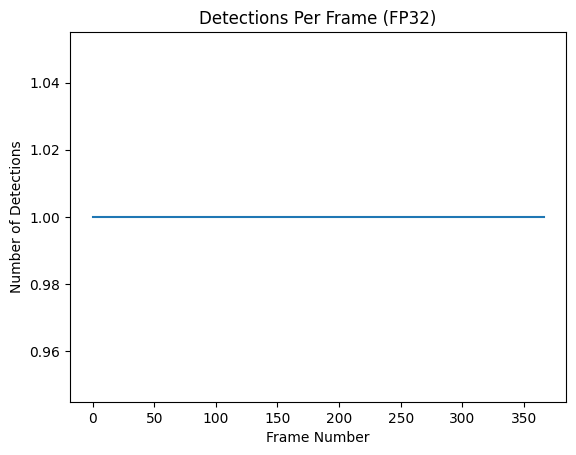

In [9]:
# COMPUTE DETECTION DENSITY PER FRAME

# Count detection per frame 
detections_per_frame = df.groupby("frame").size()
# df.groupby("frame"): groups all rows that belong to same frame number
# .size(): counts how many datections exist in each frame.

print("Average detections per frame:", detections_per_frame.mean())
print("Max detections in a single frame:", detections_per_frame.max())
print("Min detections in a single frame:", detections_per_frame.min())

plt.figure()
plt.plot(detections_per_frame)
plt.xlabel("Frame Number")
plt.ylabel("Number of Detections")
plt.title("Detections Per Frame (FP32)")
plt.show()

In [10]:
from ultralytics import YOLO
import cv2
import time

# :Load INT8 OpenVINO model
int8_model = YOLO("yolov8n_int8_openvino_model")

print("INT8 model loaded successfully")

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
INT8 model loaded successfully


In [17]:
video_path = "data/phone_walk.mp4"
cap = cv2.VideoCapture(video_path)

results_list =[]
frame_count = 0
total_time = 0
total_detections = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    start_time = time.time()

    results = int8_model(frame, imgsz = 640, conf=0.25)

    end_time = time.time()

    inference_time = end_time - start_time
    total_time += inference_time

    detections = 0

    for r in results:
        for box in r.boxes:
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            
            if confidence >=0.5:
                detections += 1

                results_list.append({
                    "frame":frame_count,
                    "class_id": class_id,
                    "confidence": confidence,
                    "inference_time": inference_time
                })

    total_detections += detections                
        

    frame_count += 1

cap.release()

avg_time = total_time/frame_count

print("INT8 Total Frames:", frame_count)
print("INT8 Average Inference Time", avg_time)
print("INT8 Toatal Detections:", total_detections)
          
df = pd.DataFrame(results_list)
df.to_csv("int8_results.csv", index=False)

print("INT8 results saved successfully.")


0: 640x640 8 persons, 5 cars, 23.3ms
Speed: 81.4ms preprocess, 23.3ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 persons, 4 cars, 23.2ms
Speed: 15.1ms preprocess, 23.2ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 6 persons, 3 cars, 18.7ms
Speed: 14.8ms preprocess, 18.7ms inference, 4.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 4 cars, 21.8ms
Speed: 11.3ms preprocess, 21.8ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 3 cars, 20.4ms
Speed: 14.8ms preprocess, 20.4ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 3 cars, 23.1ms
Speed: 13.8ms preprocess, 23.1ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 9 persons, 2 cars, 20.2ms
Speed: 12.2ms preprocess, 20.2ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 9 persons, 2 cars, 24.3ms
Speed: 13.